In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys
import typer

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)

from src.utils import configure_logger

import pandas as pd
import matplotlib.pyplot as plt

from typing import Any 
from GNN.training.utils import collect_dataset_paths
from GNN.training.runners import MODEL_REGISTRY
from GNN.training.train_config import TrainConfig
from experiments.plotting import view_correlation

from collections.abc import Callable
Loader = Callable[..., Any]

In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

## Make datasets

In [12]:
backend = "pennylane"
target = "SRE"
method = "fwht"
use_dask = True
output_dir = "/outputs/final_data/datasets_SRE"
families = "clifford,haar,quansistor"
n_seeds = 150
n_seeds_pred = 50

In [13]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=use_dask,
    n_bins_option=50,
    output_dir=output_dir,
    families=families,
    n_seeds_option=n_seeds,
    prediction_n_seeds_option=n_seeds_pred,
    qubits_min = 4,
    qubits_max = 20,
    qubits_step = 2,
    layers_min = 2,
    layers_max = 100,
    layers_step = 2,
    target_qubits = "4,6,8,10",
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

2026-06-25 19:05:59,163 - GNN.dataset_builder - INFO - Processing family: clifford
2026-06-25 19:05:59,284 - GNN.dataset_builder - INFO - Generated 68850 configs for clifford
2026-06-25 19:05:59,285 - parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-06-25 19:05:59,319 - distributed.scheduler - INFO - State start
2026-06-25 19:05:59,351 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:55293
2026-06-25 19:05:59,352 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-06-25 19:05:59,354 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-06-25 19:05:59,424 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:55300'
2026-06-25 19:05:59,429 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:55298'
2026-06-25 19:05:59,431 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:55296'
2026-06-25 19:05:59,434 - distributed.nanny -

## Train models

In [4]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [5]:
def run(
    model_type,
    epochs,
    lr,
    loss_type,
    batch_size,
    training_mode,
    family,
    target,
    model_hparams,
    train_hparams,
    training_data_dir,
    model_save_path,
    plot_qubits=10,
    plot_layers=80,
):
    training(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        model_type=model_type,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        training_data_dir=training_data_dir,
        model_save_path=model_save_path,
        show_progress=True,
        show_val_progress=False,
        log_every_n_batches=10,
        heartbeat_secs=60.0,
        epoch_time_warning_secs=600.0,
    )
    training_scope = "family" if training_mode == "per_family" else "global"
    predictions(
        model_path=model_save_path,
        model_kind=model_type,
        training_scope=training_scope,
        loss_type=loss_type,
        model_family=family,
        dataset_root=training_data_dir,
        dataset_family=family,
        batch_size=batch_size,
        global_feature_variant="binned",
        node_feature_backend_variant=None,
        plot_n_layers=plot_layers,
        plot_n_qubits=plot_qubits,
        split_by_family=True,
        show_progress=True,
    )

    df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
    cols_to_fix = ["n_qubits", "n_layers", "seed"]

    for col in cols_to_fix:
        df[col] = df[col].apply(to_scalar).astype(int)
    view_correlation(
        df,
        nq=plot_qubits,
        nl=plot_layers,
        col_x="target",
        col_y="prediction",
    )
    df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
    plt.figure(figsize=(8, 6))
    plt.scatter(df["target"], df["prediction"], alpha=0.7)
    plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
    plt.xlabel("True SRE")
    plt.ylabel("Predicted SRE")
    plt.title(f"True vs Predicted SRE for {family} Family (GNN Model)")

### Random

2026-06-26 16:40:00,684 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-26 16:40:00,685 - GNN.training.runners - INFO - Training configuration done.
2026-06-26 16:40:00,686 - GNN.training.runners - INFO - Collecting data paths...
2026-06-26 16:41:05,079 - GNN.training.runners - INFO - Found 30600 data paths.
2026-06-26 16:41:05,080 - GNN.training.runners - INFO - Data paths collected.
2026-06-26 16:41:05,081 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-26 16:42:25,020 - GNN.training.runners - INFO - Loaders and model built.
2026-06-26 16:42:25,020 - GNN.training.runners - INFO - Starting training...
2026-06-26 16:42:29,588 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  95%|█████████▍| 164/173 [01:00<00:03,  2.80it/s, loss=0.0100, graphs=21120]

2026-06-26 16:43:29,676 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 165/173 | loss 0.010043 | elapsed 60.1s | graphs 21120


2026-06-26 16:43:32,277 - GNN.training.train - INFO - Training complete (62.7s) | running validation...


2026-06-26 16:43:38,270 - GNN.training.train - INFO - Losses | train 0.009756 | val 0.001846 | lr 9.86e-04 | time train=62.7s val=6.0s total=68.7s
2026-06-26 16:43:38,272 - GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-06-26 17:17:28,349 - GNN.training.train - INFO - Losses | train 0.001024 | val 0.001126 | lr 1.23e-04 | time train=70.1s val=6.4s total=76.5s
2026-06-26 17:17:28,350 - GNN.training.train - INFO - -------- EPOCH 030 --------


Epoch 30/30:  85%|████████▍ | 147/173 [01:00<00:11,  2.31it/s, loss=0.0010, graphs=18944]

2026-06-26 17:18:28,609 - GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 148/173 | loss 0.001013 | elapsed 60.3s | graphs 18944


2026-06-26 17:18:38,068 - GNN.training.train - INFO - Training complete (69.7s) | running validation...


2026-06-26 17:18:44,275 - GNN.training.train - INFO - Losses | train 0.001002 | val 0.001343 | lr 1.23e-04 | time train=69.7s val=6.2s total=75.9s
2026-06-26 17:20:27,051 - GNN.training.runners - INFO - Training complete.


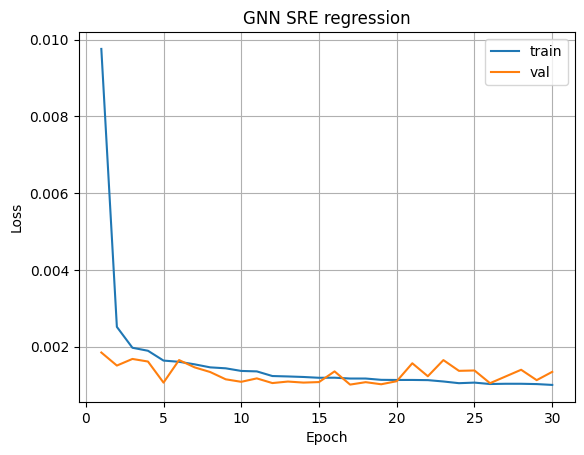

2026-06-26 17:20:27,260 - GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/random_model_gnn_per_family_SRE_density.pt
2026-06-26 17:20:27,263 - scripts.train_model - INFO - Final test loss: 0.000983
2026-06-26 17:20:27,265 - scripts.train_model - INFO - Test R2 score: 0.9698
2026-06-26 17:20:27,265 - scripts.train_model - INFO - Validation R2 score: 0.9689
2026-06-26 17:20:27,266 - scripts.train_model - INFO - Training R2 score: 0.9708
2026-06-26 17:20:27,267 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/random_model_gnn_per_family_SRE_density.pt
2026-06-26 17:20:45,896 - scripts.predictions - INFO - Found 68850 prediction files
Predicting (gnn): 100%|██████████| 538/538 [06:49<00:00,  1.31batch/s]
2026-06-26 17:27:40,293 - scripts.predictions - INFO - Saved 68850 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-06-26 17:27:40,467 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predi

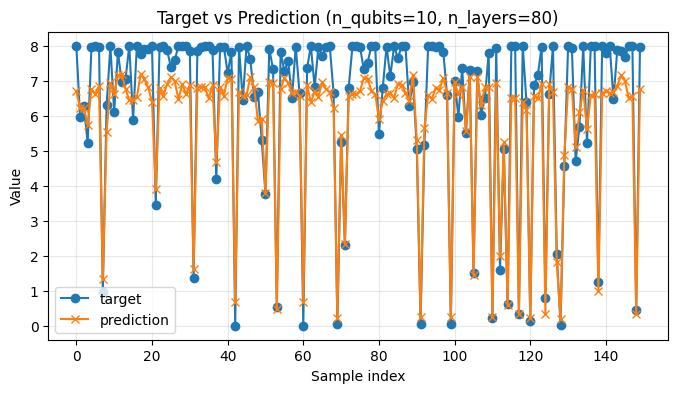

Pearson r = 0.9676


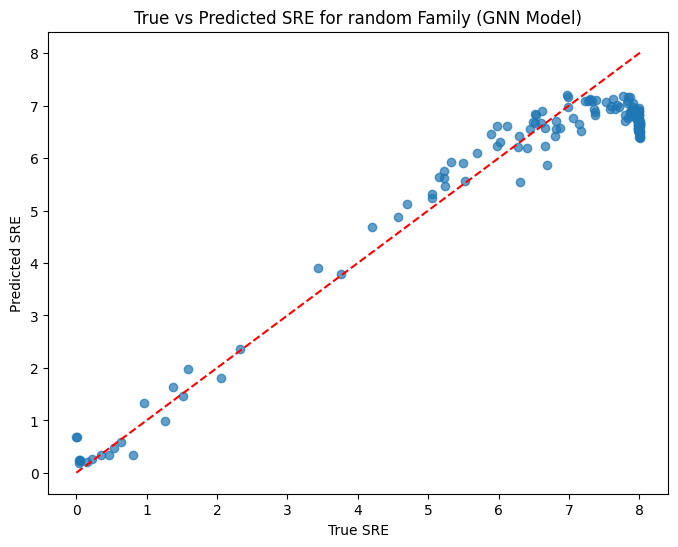

In [9]:
model_type="gnn"
epochs = 30
lr = 0.0009860340204413903
loss_type = "huber"   # "mse" | "huber"
batch_size = 128
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/final_data/datasets_SRE"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}_SRE_density.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100


model_hparams = {
    "gnn_hidden" : 64,
    "gnn_heads": 2,
    "global_hidden": 32,
    "reg_hidden": 128,
    "num_layers": 6,
    "dropout_rate": 0.06640302989664926,
}

train_hparams = {
    "weight_decay": 3.0500428108369453e-05,
    "grad_clip": 4.379744711312854,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 0.0,
}


run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

### Clifford

2026-06-26 17:27:43,170 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=clifford | loss_type=huber
2026-06-26 17:27:43,172 - GNN.training.runners - INFO - Training configuration done.
2026-06-26 17:27:43,172 - GNN.training.runners - INFO - Collecting data paths...
2026-06-26 17:28:49,570 - GNN.training.runners - INFO - Found 30600 data paths.
2026-06-26 17:28:49,572 - GNN.training.runners - INFO - Data paths collected.
2026-06-26 17:28:49,572 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-26 17:29:35,614 - GNN.training.runners - INFO - Loaders and model built.
2026-06-26 17:29:35,615 - GNN.training.runners - INFO - Starting training...
2026-06-26 17:29:35,635 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  70%|██████▉   | 482/689 [01:00<00:22,  9.32it/s, loss=0.0197, graphs=15456]

2026-06-26 17:30:35,690 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 483/689 | loss 0.019656 | elapsed 60.1s | graphs 15456


2026-06-26 17:31:01,548 - GNN.training.train - INFO - Training complete (85.9s) | running validation...


2026-06-26 17:31:06,948 - GNN.training.train - INFO - Losses | train 0.017150 | val 0.009619 | lr 2.52e-05 | time train=85.9s val=5.4s total=91.3s
2026-06-26 17:31:06,952 - GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-06-26 18:25:15,578 - GNN.training.train - INFO - Losses | train 0.004402 | val 0.003881 | lr 2.52e-05 | time train=139.6s val=9.0s total=148.6s
2026-06-26 18:25:15,582 - GNN.training.train - INFO - -------- EPOCH 030 --------


Epoch 30/30:  43%|████▎     | 298/689 [01:01<00:50,  7.75it/s, loss=0.0044, graphs=9568]

2026-06-26 18:26:16,687 - GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 299/689 | loss 0.004379 | elapsed 61.1s | graphs 9568


2026-06-26 18:27:13,759 - GNN.training.train - INFO - Training complete (118.2s) | running validation...


2026-06-26 18:27:18,815 - GNN.training.train - INFO - Losses | train 0.004394 | val 0.004181 | lr 2.52e-05 | time train=118.2s val=5.1s total=123.2s
2026-06-26 18:28:40,855 - GNN.training.runners - INFO - Training complete.


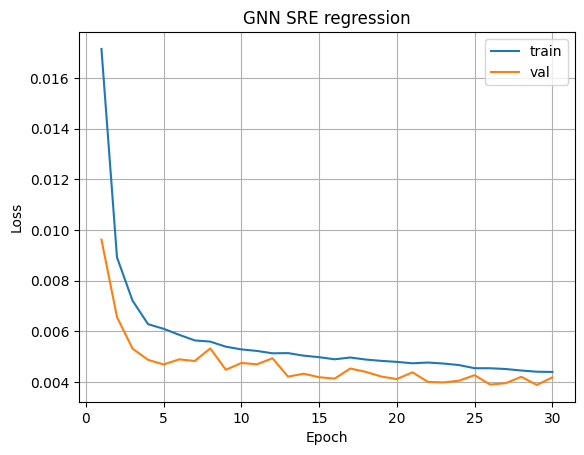

2026-06-26 18:28:41,174 - GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/clifford_model_gnn_per_family_SRE_density.pt
2026-06-26 18:28:41,180 - scripts.train_model - INFO - Final test loss: 0.003872
2026-06-26 18:28:41,182 - scripts.train_model - INFO - Test R2 score: 0.8569
2026-06-26 18:28:41,183 - scripts.train_model - INFO - Validation R2 score: 0.8573
2026-06-26 18:28:41,183 - scripts.train_model - INFO - Training R2 score: 0.8612
2026-06-26 18:28:41,185 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/clifford_model_gnn_per_family_SRE_density.pt
2026-06-26 18:29:06,813 - scripts.predictions - INFO - Found 68850 prediction files
Predicting (gnn): 100%|██████████| 2152/2152 [03:45<00:00,  9.53batch/s]
2026-06-26 18:32:58,350 - scripts.predictions - INFO - Saved 68850 predictions to ../outputs/predictions/family/gnn_predictions_clifford.csv
2026-06-26 18:32:58,513 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figur

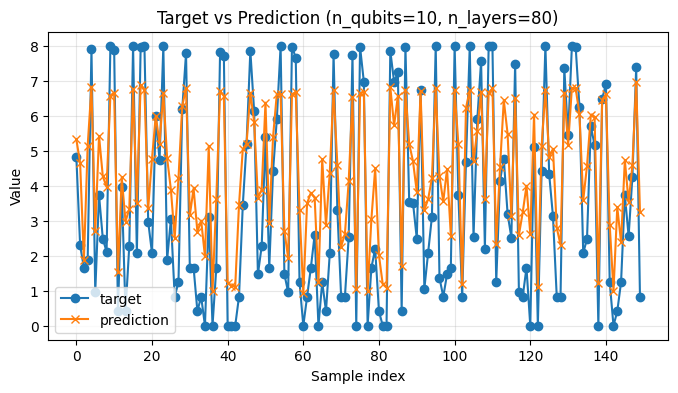

Pearson r = 0.9298


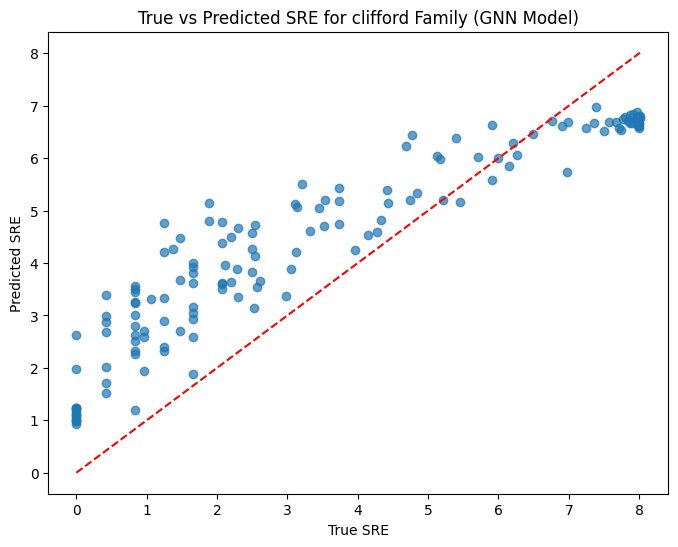

In [10]:
model_type="gnn"
epochs = 30
lr = 2.5223176427539664e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/final_data/datasets_SRE"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}_SRE_density.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

model_hparams = {
    "gnn_hidden" : 128,
    "gnn_heads": 2,
    "global_hidden": 16,
    "reg_hidden": 32,
    "num_layers": 6,
    "dropout_rate": 0.014842423657881243,
}

train_hparams = {
    "weight_decay": 1.0439900428164368e-05,
    "grad_clip":  0.011242628935673588,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 0.0,
}


run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

### Haar

2026-06-26 18:33:01,268 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=haar | loss_type=huber
2026-06-26 18:33:01,270 - GNN.training.runners - INFO - Training configuration done.
2026-06-26 18:33:01,270 - GNN.training.runners - INFO - Collecting data paths...
2026-06-26 18:34:05,489 - GNN.training.runners - INFO - Found 30600 data paths.
2026-06-26 18:34:05,490 - GNN.training.runners - INFO - Data paths collected.
2026-06-26 18:34:05,490 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-26 18:35:00,897 - GNN.training.runners - INFO - Loaders and model built.
2026-06-26 18:35:00,898 - GNN.training.runners - INFO - Starting training...
2026-06-26 18:35:00,901 - GNN.training.train - INFO - -------- EPOCH 001 --------


2026-06-26 18:35:51,737 - GNN.training.train - INFO - Training complete (50.8s) | running validation...


2026-06-26 18:35:56,467 - GNN.training.train - INFO - Losses | train 0.003891 | val 0.001537 | lr 5.46e-04 | time train=50.8s val=4.7s total=55.6s
2026-06-26 18:35:56,470 - GNN.training.train - INFO - -------- EPOCH 002 --------


2026-06-26 18:36:49,319 - GNN.training.train - INFO - Training complete (52.8s) | running validation...


2026-06-26 18:36:53,764 - GNN.training.train - INFO - Losses | train 0.001831 | val 0.001588 | lr 5.46e-04 | time train=52.8s val=4.4s total=57.3s
2026-06-26 18:36:53,765 - GNN.training.train - INFO - -------- EPOCH 003 --------


...

2026-06-26 19:00:44,033 - GNN.training.train - INFO - Losses | train 0.001176 | val 0.001272 | lr 2.73e-04 | time train=51.2s val=4.3s total=55.6s
2026-06-26 19:00:44,034 - GNN.training.train - INFO - -------- EPOCH 029 --------


2026-06-26 19:01:33,254 - GNN.training.train - INFO - Training complete (49.2s) | running validation...


2026-06-26 19:01:37,582 - GNN.training.train - INFO - Losses | train 0.001198 | val 0.001211 | lr 2.73e-04 | time train=49.2s val=4.3s total=53.5s
2026-06-26 19:01:37,584 - GNN.training.train - INFO - -------- EPOCH 030 --------


2026-06-26 19:02:28,243 - GNN.training.train - INFO - Training complete (50.7s) | running validation...


2026-06-26 19:02:32,524 - GNN.training.train - INFO - Losses | train 0.001185 | val 0.001220 | lr 2.73e-04 | time train=50.7s val=4.3s total=54.9s
2026-06-26 19:03:41,311 - GNN.training.runners - INFO - Training complete.


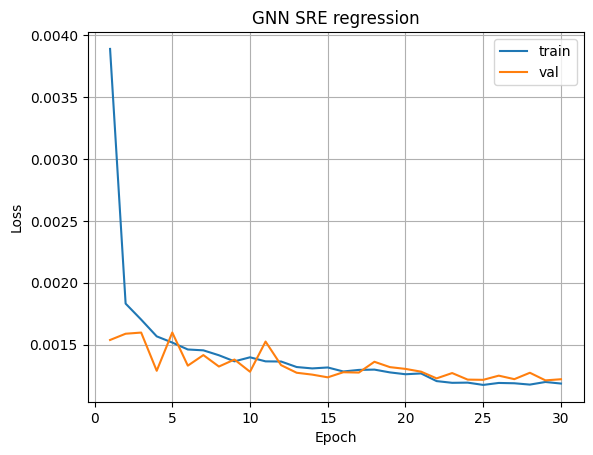

2026-06-26 19:03:41,420 - GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/haar_model_gnn_per_family_SRE_density.pt
2026-06-26 19:03:41,421 - scripts.train_model - INFO - Final test loss: 0.001068
2026-06-26 19:03:41,421 - scripts.train_model - INFO - Test R2 score: 0.9663
2026-06-26 19:03:41,421 - scripts.train_model - INFO - Validation R2 score: 0.9620
2026-06-26 19:03:41,423 - scripts.train_model - INFO - Training R2 score: 0.9668
2026-06-26 19:03:41,423 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/haar_model_gnn_per_family_SRE_density.pt
2026-06-26 19:03:57,269 - scripts.predictions - INFO - Found 68850 prediction files
Predicting (gnn): 100%|██████████| 4304/4304 [03:07<00:00, 22.90batch/s]
2026-06-26 19:07:09,974 - scripts.predictions - INFO - Saved 68850 predictions to ../outputs/predictions/family/gnn_predictions_haar.csv
2026-06-26 19:07:10,120 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictio

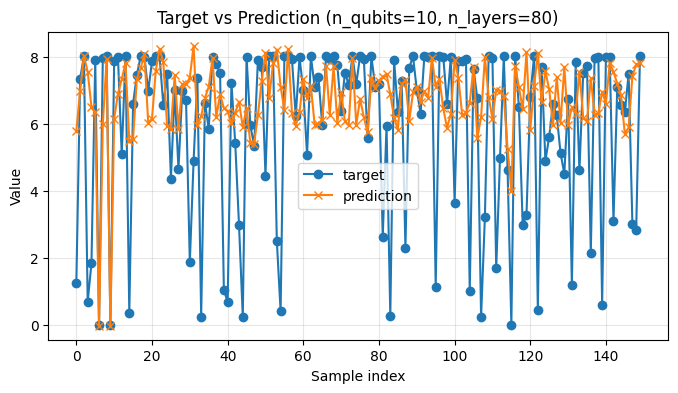

Pearson r = 0.2141


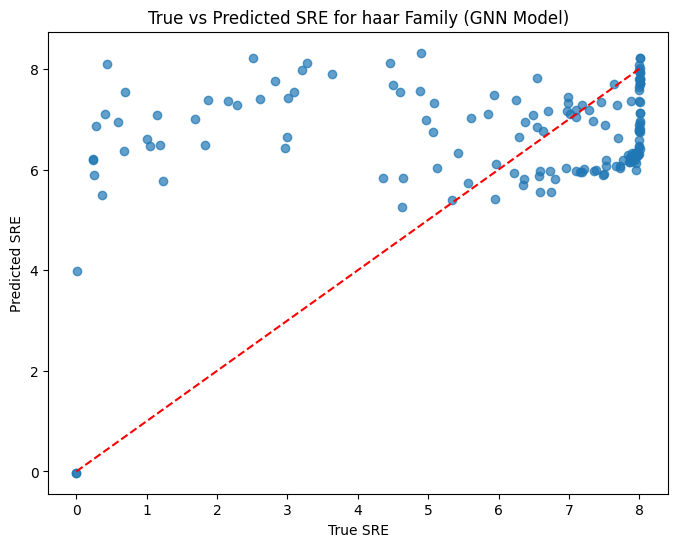

In [11]:
model_type="gnn"
epochs = 30
lr = 0.0005456850011484297
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "haar"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/final_data/datasets_SRE"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}_SRE_density.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

model_hparams = {
    "gnn_hidden" : 64,
    "gnn_heads": 2,
    "global_hidden": 128,
    "reg_hidden": 16,
    "num_layers": 2,
    "dropout_rate": 0.004127592869557634,
}

train_hparams = {
    "weight_decay": 1.560010639264171e-05,
    "grad_clip": 7.2440146231033875,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 0.0,
}


run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

### Quansistor

2026-06-26 12:43:47,820 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=quansistor | loss_type=huber
2026-06-26 12:43:47,820 - GNN.training.runners - INFO - Training configuration done.
2026-06-26 12:43:47,822 - GNN.training.runners - INFO - Collecting data paths...
2026-06-26 12:45:02,891 - GNN.training.runners - INFO - Found 30600 data paths.
2026-06-26 12:45:02,892 - GNN.training.runners - INFO - Data paths collected.
2026-06-26 12:45:02,893 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-26 12:46:59,977 - GNN.training.runners - INFO - Loaders and model built.
2026-06-26 12:46:59,977 - GNN.training.runners - INFO - Starting training...
2026-06-26 12:47:01,002 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  32%|███▏      | 223/689 [01:00<03:38,  2.13it/s, loss=0.0763, graphs=7168]

2026-06-26 12:48:01,110 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 224/689 | loss 0.076332 | elapsed 60.1s | graphs 7168


Epoch 1/30:  60%|██████    | 415/689 [02:01<01:14,  3.68it/s, loss=0.0596, graphs=13312]

2026-06-26 12:49:02,223 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 416/689 | loss 0.059564 | elapsed 121.2s | graphs 13312


...

2026-06-26 14:57:09,580 - GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 258/689 | loss 0.008342 | elapsed 60.1s | graphs 8256


Epoch 30/30:  75%|███████▍  | 514/689 [02:01<00:33,  5.18it/s, loss=0.0083, graphs=16480]

2026-06-26 14:58:11,009 - GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 515/689 | loss 0.008274 | elapsed 121.5s | graphs 16480


2026-06-26 14:58:50,630 - GNN.training.train - INFO - Training complete (161.1s) | running validation...


2026-06-26 14:59:01,459 - GNN.training.train - INFO - Losses | train 0.008258 | val 0.004195 | lr 1.06e-05 | time train=161.1s val=10.8s total=171.9s
2026-06-26 15:02:13,226 - GNN.training.runners - INFO - Training complete.


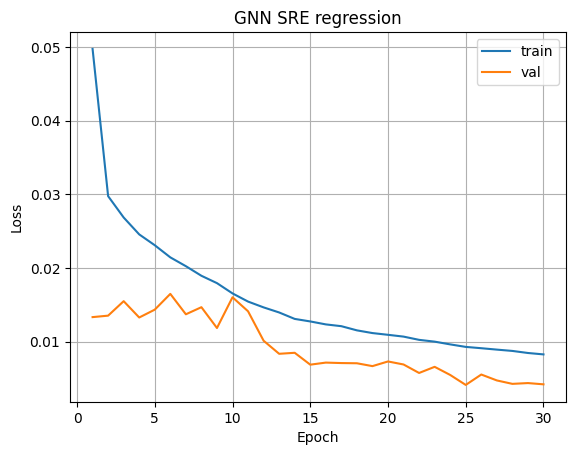

2026-06-26 15:02:13,378 - GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/quansistor_model_gnn_per_family_SRE_density.pt
2026-06-26 15:02:13,383 - scripts.train_model - INFO - Final test loss: 0.004224
2026-06-26 15:02:13,383 - scripts.train_model - INFO - Test R2 score: 0.8349
2026-06-26 15:02:13,383 - scripts.train_model - INFO - Validation R2 score: 0.8315
2026-06-26 15:02:13,384 - scripts.train_model - INFO - Training R2 score: 0.8376
2026-06-26 15:02:13,384 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/quansistor_model_gnn_per_family_SRE_density.pt
2026-06-26 15:02:31,627 - scripts.predictions - INFO - Found 68850 prediction files
Predicting (gnn): 100%|██████████| 2152/2152 [51:28<00:00,  1.44s/batch]  
2026-06-26 15:54:05,638 - scripts.predictions - INFO - Saved 68850 predictions to ../outputs/predictions/family/gnn_predictions_quansistor.csv
2026-06-26 15:54:05,914 - scripts.predictions - INFO - Saved fixed-layer plot to ../outpu

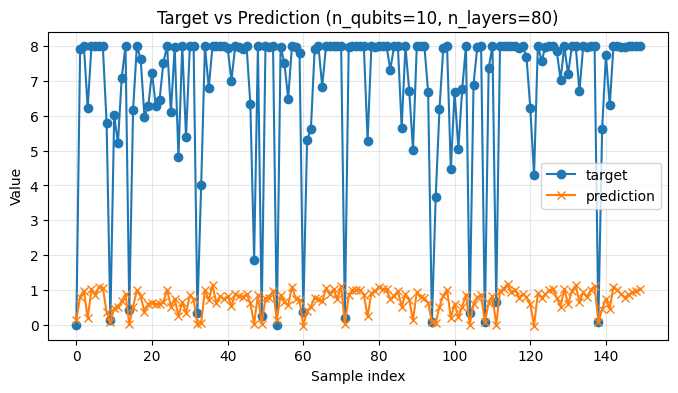

Pearson r = 0.8811


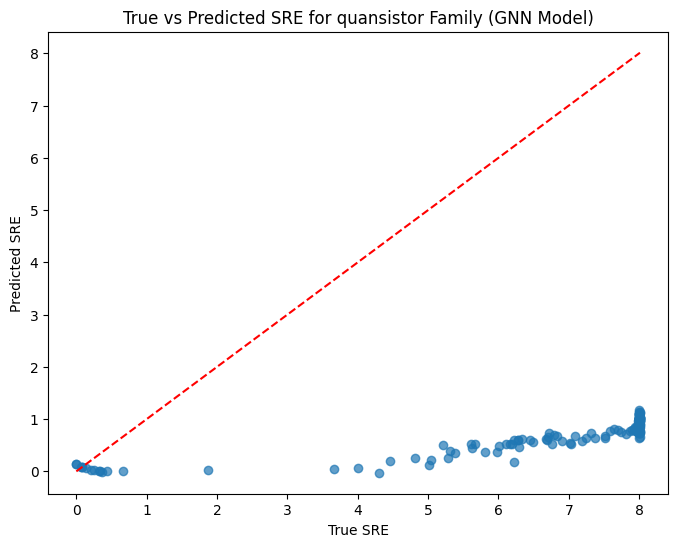

In [8]:
model_type="gnn"
epochs = 30
lr = 1.0600038808287122e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "quansistor"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/final_data/datasets_SRE"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}_SRE_density.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

model_hparams = {
    "gnn_hidden" : 128,
    "gnn_heads": 8,
    "global_hidden": 16,
    "reg_hidden": 64,
    "num_layers": 3,
    "dropout_rate": 0.4050959484660077,
}

train_hparams = {
    "weight_decay": 0.0006626449388616718,
    "grad_clip":  4.779019014790367,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 0.0,
}


run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)